# EU Progress Report Scoring Pipeline
End-to-end demo: raw scraped text → paragraph corpus → criticism scores → country-year summary + plots.

## Step 1 — Build paragraph corpus

In [1]:
from corpus import build_corpus

df = build_corpus("scraped/raw", min_words=50, max_words=500)

print(f"Total paragraphs : {len(df):,}")
print(f"Countries        : {sorted(df['country'].unique())}")
print(f"Years            : {sorted(df['year'].unique())}")
df.head(3)

  Albania                   2019  →  444 paragraphs
  Albania                   2020  →  547 paragraphs
  Albania                   2021  →  576 paragraphs
  Albania                   2022  →  538 paragraphs
  Albania                   2023  →  591 paragraphs
  Albania                   2024  →  363 paragraphs
  Albania                   2025  →  376 paragraphs
  Bosnia And Herzegovina    2020  →  497 paragraphs
  Bosnia And Herzegovina    2021  →  519 paragraphs
  Bosnia And Herzegovina    2022  →  548 paragraphs
  Bosnia And Herzegovina    2023  →  591 paragraphs
  Bosnia And Herzegovina    2024  →  368 paragraphs
  Bosnia And Herzegovina    2025  →  394 paragraphs
  Georgia                   2023  →  522 paragraphs
  Georgia                   2024  →  362 paragraphs
  Georgia                   2025  →  290 paragraphs
  Kosovo                    2019  →  395 paragraphs
  Kosovo                    2020  →  481 paragraphs
  Kosovo                    2021  →  457 paragraphs
  Kosovo    

,country,year,paragraph_id,paragraph_text,word_count
0,Albania,2019,0,Democracy 6 2.1.2. Public administration re...,72
1,Albania,2019,1,Albania has continued to implement the Stabili...,115
2,Albania,2019,2,Parliamentary activities were affected by a pr...,94


### Paragraph size distribution

count    26764.0
mean       107.9
std         69.8
min         50.0
25%         66.0
50%         88.0
75%        125.0
max        811.0


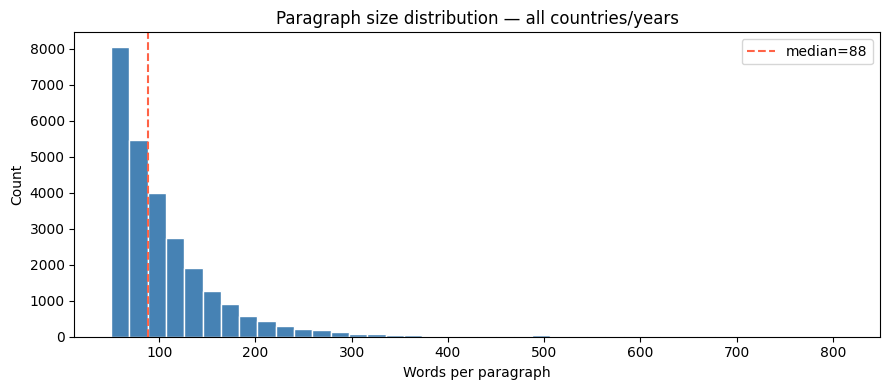

In [2]:
import matplotlib.pyplot as plt

wc = df["word_count"]
print(wc.describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(wc, bins=40, color="steelblue", edgecolor="white")
ax.axvline(wc.median(), color="tomato", linestyle="--", label=f"median={wc.median():.0f}")
ax.set_xlabel("Words per paragraph")
ax.set_ylabel("Count")
ax.set_title("Paragraph size distribution — all countries/years")
ax.legend()
plt.tight_layout()
plt.show()

## Step 2 — Score paragraphs

In [3]:
from score import score_corpus

df_scored = score_corpus(df)

print(f"Paragraphs with any hard criticism : {(df_scored['criticism_hard_p1k'] > 0).sum():,}")
print(f"Paragraphs with any soft criticism : {(df_scored['criticism_soft_p1k'] > 0).sum():,}")
print(f"Paragraphs with severity score     : {df_scored['severity_ratio'].notna().sum():,}")
df_scored[["country","year","paragraph_id","word_count",
           "criticism_hard_p1k","criticism_soft_p1k","severity_ratio"]].head(5)

Paragraphs with any hard criticism : 4,620
Paragraphs with any soft criticism : 17,833
Paragraphs with severity score     : 17,833


,country,year,paragraph_id,word_count,criticism_hard_p1k,criticism_soft_p1k,severity_ratio
0,Albania,2019,0,72,0.0,0.0,NaN
1,Albania,2019,1,115,0.0,0.0,NaN
2,Albania,2019,2,94,0.0,0.0,NaN
3,Albania,2019,3,95,0.0,0.0,NaN
4,Albania,2019,4,171,0.0,0.0,NaN


## Step 3 — Aggregate to country-year level

In [4]:
from score import aggregate_country_year

agg = aggregate_country_year(df_scored)
print(agg.to_string(index=False))

               country  year  criticism_hard_p1k  criticism_soft_p1k  severity_ratio
               Albania  2019              1.4618             21.3927          0.0723
               Albania  2020              1.2345             20.1961          0.0657
               Albania  2021              1.2019             19.1759          0.0561
               Albania  2022              1.2767             22.1027          0.0681
               Albania  2023              1.5470             25.5129          0.0670
               Albania  2024              1.3549             24.3694          0.0567
               Albania  2025              2.0698             27.4993          0.0887
Bosnia And Herzegovina  2020              3.8650             28.1994          0.1830
Bosnia And Herzegovina  2021              3.8327             28.8028          0.1426
Bosnia And Herzegovina  2022              3.4687             27.8572          0.1653
Bosnia And Herzegovina  2023              3.1847             28.5

## Step 4 — Plots

In [5]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

all_countries = sorted(agg["country"].unique())
colors = {c: cm.tab10(i / len(all_countries)) for i, c in enumerate(all_countries)}

country_selector = widgets.SelectMultiple(
    options=all_countries,
    value=all_countries,
    description="Countries",
    layout=widgets.Layout(width="220px", height="180px"),
)

out = widgets.Output()

def plot(selected):
    out.clear_output(wait=True)
    with out:
        if not selected:
            print("Select at least one country.")
            return
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle("Criticism Scores by Country-Year", fontsize=13, fontweight="bold")

        def line_plot(ax, col, title, ylabel):
            for country in selected:
                d = agg[agg["country"] == country].sort_values("year")
                ax.plot(d["year"], d[col], marker="o", label=country, color=colors[country])
            ax.set_title(title, fontsize=11)
            ax.set_ylabel(ylabel)
            ax.set_xlabel("Year")
            ax.legend(fontsize=7, ncol=2)
            ax.grid(True, alpha=0.3)

        line_plot(axes[0], "criticism_hard_p1k", "Hard Criticism",  "score p1k")
        line_plot(axes[1], "criticism_soft_p1k", "Soft Criticism",  "score p1k")
        line_plot(axes[2], "severity_ratio",      "Severity Ratio",  "hard / soft")

        plt.tight_layout()
        plt.show()

widgets.interactive_output(plot, {"selected": country_selector})
display(widgets.HBox([country_selector, out]))
plot(all_countries)

## Step 4b — Topic tagging

In [6]:
from score import tag_topics

df_scored = tag_topics(df_scored)

topic_cols = [c for c in df_scored.columns if c.startswith("topic_")]
topic_counts = df_scored[topic_cols].sum().rename(lambda c: c.replace("topic_", ""))

print("Paragraphs flagged per topic (corpus-wide):")
print(topic_counts.to_string())
print()
print(f"Paragraphs with at least one topic : {df_scored[topic_cols].any(axis=1).sum():,}")
print(f"Paragraphs with no topic match     : {(~df_scored[topic_cols].any(axis=1)).sum():,}")
print()
print(f"Mean topics per paragraph          : {df_scored[topic_cols].sum(axis=1).mean():.2f}")
df_scored[topic_cols].head(5)

Paragraphs flagged per topic (corpus-wide):
judiciary_rule_of_law                5613
corruption_anti_corruption           3410
public_administration_governance     4110
political_functioning               10847
economy_market                       7594

Paragraphs with at least one topic : 19,766
Paragraphs with no topic match     : 6,998

Mean topics per paragraph          : 1.18


,topic_judiciary_rule_of_law,topic_corruption_anti_corruption,topic_public_administration_governance,topic_political_functioning,topic_economy_market
0,True,False,True,True,True
1,True,False,False,False,False
2,False,False,False,True,False
3,True,False,False,False,False
4,True,True,False,True,False


## Step 4c — Topic-level criticism scores

In [7]:
from score import aggregate_by_topic
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ipywidgets as widgets
from IPython.display import display

agg_topic = aggregate_by_topic(df_scored)

print(f"Rows: {len(agg_topic)}  (country × year × topic)")
agg_topic.head(10)

Rows: 285  (country × year × topic)


,country,year,topic,n_paragraphs,criticism_hard_p1k,criticism_soft_p1k,severity_ratio
0,Albania,2019,judiciary_rule_of_law,76,2.0398,21.7310,0.0786
1,Albania,2020,judiciary_rule_of_law,90,2.0471,19.7111,0.0949
2,Albania,2021,judiciary_rule_of_law,96,1.4931,18.8815,0.0807
3,Albania,2022,judiciary_rule_of_law,94,1.1907,18.5737,0.0666
4,Albania,2023,judiciary_rule_of_law,108,1.8692,23.1949,0.0682
5,Albania,2024,judiciary_rule_of_law,61,3.8060,26.1454,0.1539
6,Albania,2025,judiciary_rule_of_law,60,5.6669,28.8197,0.2100
7,Bosnia And Herzegovina,2020,judiciary_rule_of_law,104,5.4936,32.6192,0.2306
8,Bosnia And Herzegovina,2021,judiciary_rule_of_law,113,6.5303,31.7473,0.2145
9,Bosnia And Herzegovina,2022,judiciary_rule_of_law,120,5.1005,25.2400,0.2215


In [ ]:
# --- Interactive heatmap: pick metric and year ---
all_topics    = sorted(agg_topic["topic"].unique())
all_countries = sorted(agg_topic["country"].unique())
all_years     = sorted(agg_topic["year"].unique())

metric_selector = widgets.Dropdown(
    options=[
        ("Hard criticism",  "criticism_hard_p1k"),
        ("Soft criticism",  "criticism_soft_p1k"),
        ("Severity ratio",  "severity_ratio"),
    ],
    value="criticism_hard_p1k",
    description="Metric:",
    layout=widgets.Layout(width="260px"),
)

year_selector = widgets.SelectMultiple(
    options=all_years,
    value=all_years,
    description="Years:",
    layout=widgets.Layout(width="160px", height="160px"),
)

country_selector = widgets.SelectMultiple(
    options=all_countries,
    value=all_countries,
    description="Countries:",
    layout=widgets.Layout(width="220px", height="160px"),
)

out = widgets.Output()

def draw(metric, years, countries):
    out.clear_output(wait=True)
    with out:
        sub = agg_topic[
            agg_topic["year"].isin(years) &
            agg_topic["country"].isin(countries)
        ].copy()

        sub["country_year"] = sub["country"] + " (" + sub["year"].astype(str) + ")"
        pivot = sub.pivot_table(index="topic", columns="country_year", values=metric)

        fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns) * 0.9), 4))
        im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([t.replace("_", " ") for t in pivot.index], fontsize=9)
        ax.set_title(f"{metric}  by topic x country-year", fontsize=11)
        plt.tight_layout()
        plt.show()

widgets.interactive_output(draw, {"metric": metric_selector, "years": year_selector, "countries": country_selector})
controls = widgets.HBox([metric_selector, year_selector, country_selector])
display(controls, out)
draw(metric_selector.value, all_years, all_countries)

Output()

## Step 5 — Save outputs

In [9]:
from pathlib import Path
Path("data").mkdir(exist_ok=True)

df.to_csv("data/paragraphs.csv", index=False)
df_scored.to_csv("data/scores.csv", index=False)
agg.to_csv("data/summary.csv", index=False)

print("Saved:")
print(f"  data/paragraphs.csv  ({len(df):,} rows)")
print(f"  data/scores.csv      ({len(df_scored):,} rows)")
print(f"  data/summary.csv     ({len(agg):,} rows)")

Saved:
  data/paragraphs.csv  (26,764 rows)
  data/scores.csv      (26,764 rows)
  data/summary.csv     (57 rows)


## Step 6 — Logistic regression: predictors of hard criticism

**DV:** `hard_flag` — whether a paragraph contains any hard criticism (binary)  
**IVs:** topic dummies · `year` (linear trend) · country fixed effects

Each observation is a paragraph. Countries are modelled as fixed effects (dummies); one country is the reference category. `year` enters as a continuous variable to capture a linear time trend.

> Note: paragraphs can belong to multiple topics simultaneously, so topic dummies are included side-by-side (not mutually exclusive).

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ── 1. Build regression dataset ─────────────────────────────────────────────
reg = df_scored.copy()

# Binary DV
reg["hard_flag"] = (reg["criticism_hard_p1k"] > 0).astype(int)

# Topic columns
topic_cols = [c for c in reg.columns if c.startswith("topic_")]
for c in topic_cols:
    reg[c] = reg[c].astype(int)

# Short topic names for display
topic_labels = {c: c.replace("topic_", "").replace("_", " ") for c in topic_cols}

# Centre year so the intercept is meaningful
reg["year_c"] = reg["year"] - reg["year"].median()

# Reference country: Albania (first alphabetically)
ref_country = sorted(reg["country"].unique())[0]
print(f"Reference country : {ref_country}")
print(f"Reference year    : {reg['year'].median():.0f} (year_c = 0)")
print(f"N paragraphs      : {len(reg):,}")
print(f"Hard-flag rate    : {reg['hard_flag'].mean():.1%}\n")

# ── 2. Fit logistic regression ───────────────────────────────────────────────
topic_terms = " + ".join(topic_cols)
formula = f"hard_flag ~ {topic_terms} + year_c + C(country, Treatment('{ref_country}'))"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model = smf.logit(formula, data=reg).fit(disp=False)

print(model.summary2())


In [ ]:
# ── 3. Odds-ratio plot ───────────────────────────────────────────────────────
res = pd.DataFrame({
    "coef": model.params,
    "lower": model.conf_int()[0],
    "upper": model.conf_int()[1],
    "pval":  model.pvalues,
}).drop("Intercept")

# Exponentiate → odds ratios
or_df = np.exp(res)
or_df["pval"] = res["pval"]
or_df["sig"]  = or_df["pval"] < 0.05

# ── 3a. Topic & time coefficients ───────────────────────────────────────────
topic_time_mask = or_df.index.str.startswith("topic_") | or_df.index.str.startswith("year_c")
tt = or_df[topic_time_mask].copy()

# Clean labels
def clean_label(s):
    s = s.replace("topic_", "").replace("_", " ")
    s = s.replace("year c", "year (linear trend)")
    return s

tt.index = [clean_label(i) for i in tt.index]

fig, ax = plt.subplots(figsize=(7, len(tt) * 0.55 + 1))
colors = ["steelblue" if s else "lightgrey" for s in tt["sig"]]
ax.barh(tt.index, tt["coef"] - 1, left=1, color=colors, edgecolor="white", height=0.6)
ax.errorbar(
    tt["coef"], range(len(tt)),
    xerr=[tt["coef"] - tt["lower"], tt["upper"] - tt["coef"]],
    fmt="none", color="black", capsize=3, linewidth=1,
)
ax.axvline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Odds ratio  (reference: Albania, year = 2022)")
ax.set_title("Topic & time predictors of hard criticism\n(blue = p < 0.05)", fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── 3b. Country fixed effects ────────────────────────────────────────────────
country_mask = or_df.index.str.startswith("C(country")
ct = or_df[country_mask].copy()
ct.index = ct.index.str.extract(r"T\.(.+?)\]")[0].values

ct = ct.sort_values("coef")

fig, ax = plt.subplots(figsize=(7, len(ct) * 0.55 + 1))
colors = ["tomato" if s else "lightgrey" for s in ct["sig"]]
ax.barh(ct.index, ct["coef"] - 1, left=1, color=colors, edgecolor="white", height=0.6)
ax.errorbar(
    ct["coef"], range(len(ct)),
    xerr=[ct["coef"] - ct["lower"], ct["upper"] - ct["coef"]],
    fmt="none", color="black", capsize=3, linewidth=1,
)
ax.axvline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Odds ratio  (reference: Albania)")
ax.set_title("Country fixed effects on hard criticism\n(red = p < 0.05)", fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── 4. Summary table (odds ratios + CI + p) ──────────────────────────────────
summary = or_df[["coef","lower","upper","pval"]].rename(columns={
    "coef": "Odds Ratio", "lower": "CI 2.5%", "upper": "CI 97.5%", "pval": "p-value"
})
summary.index = [
    clean_label(i) if not i.startswith("C(country") else
    "country: " + i.split("T.")[1].rstrip("]")
    for i in or_df.index
]
summary.round(3)
